# GOES-18 ABI SO₂ / Volcanic Emissions RGB — Shishaldin

A single SO₂ / Volcanic Emissions RGB image over Shishaldin on
3 October 2023, 19:00 UTC.

Satpy's current name for this composite is `volcanic_emissions` (the old
`so2` name is deprecated). It is a qualitative gas view, not a
concentration retrieval. See
[docs/RGB.md](../docs/RGB.md#goes-abi-so-volcanic-emissions-rgb).

## Setup

In [1]:
import logging
import sys
import warnings
from pathlib import Path

from IPython.display import Image, display
from satpy import Scene
from satpy.utils import PerformanceWarning

logging.getLogger("pyspectral.rsr_reader").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=PerformanceWarning)
warnings.filterwarnings("ignore", message="Mean of empty slice", category=RuntimeWarning)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from examples.domains import DOMAINS
from examples.goes18_coverage_data import SCAN_LABELS, download_coverage
from examples.render_satellite import crop_and_resample_scene, save_map


## Parameters

In [2]:
PRODUCT_LABEL = "SO₂ / Volcanic Emissions RGB"

# One named domain from examples/domains.py (edit it there for your own area).
DOMAIN_NAME = "shishaldin"
DOMAIN = DOMAINS[DOMAIN_NAME]
DOMAIN_RESOLUTION = 0.02

CHANNELS = ("C09", "C10", "C11", "C13")
COMPOSITE = "volcanic_emissions"

DATA_DIR = REPO_ROOT / "data" / "goes18-20231003-1900"
OUTPUT = REPO_ROOT / "output" / "goes18_volcanic_emissions_shishaldin.png"
OUTPUT.parent.mkdir(parents=True, exist_ok=True)


## Render

Download the channels (`C09`, `C10`, `C11`, `C13`), build the
`volcanic_emissions` composite, crop to the Shishaldin domain, and save
one image.

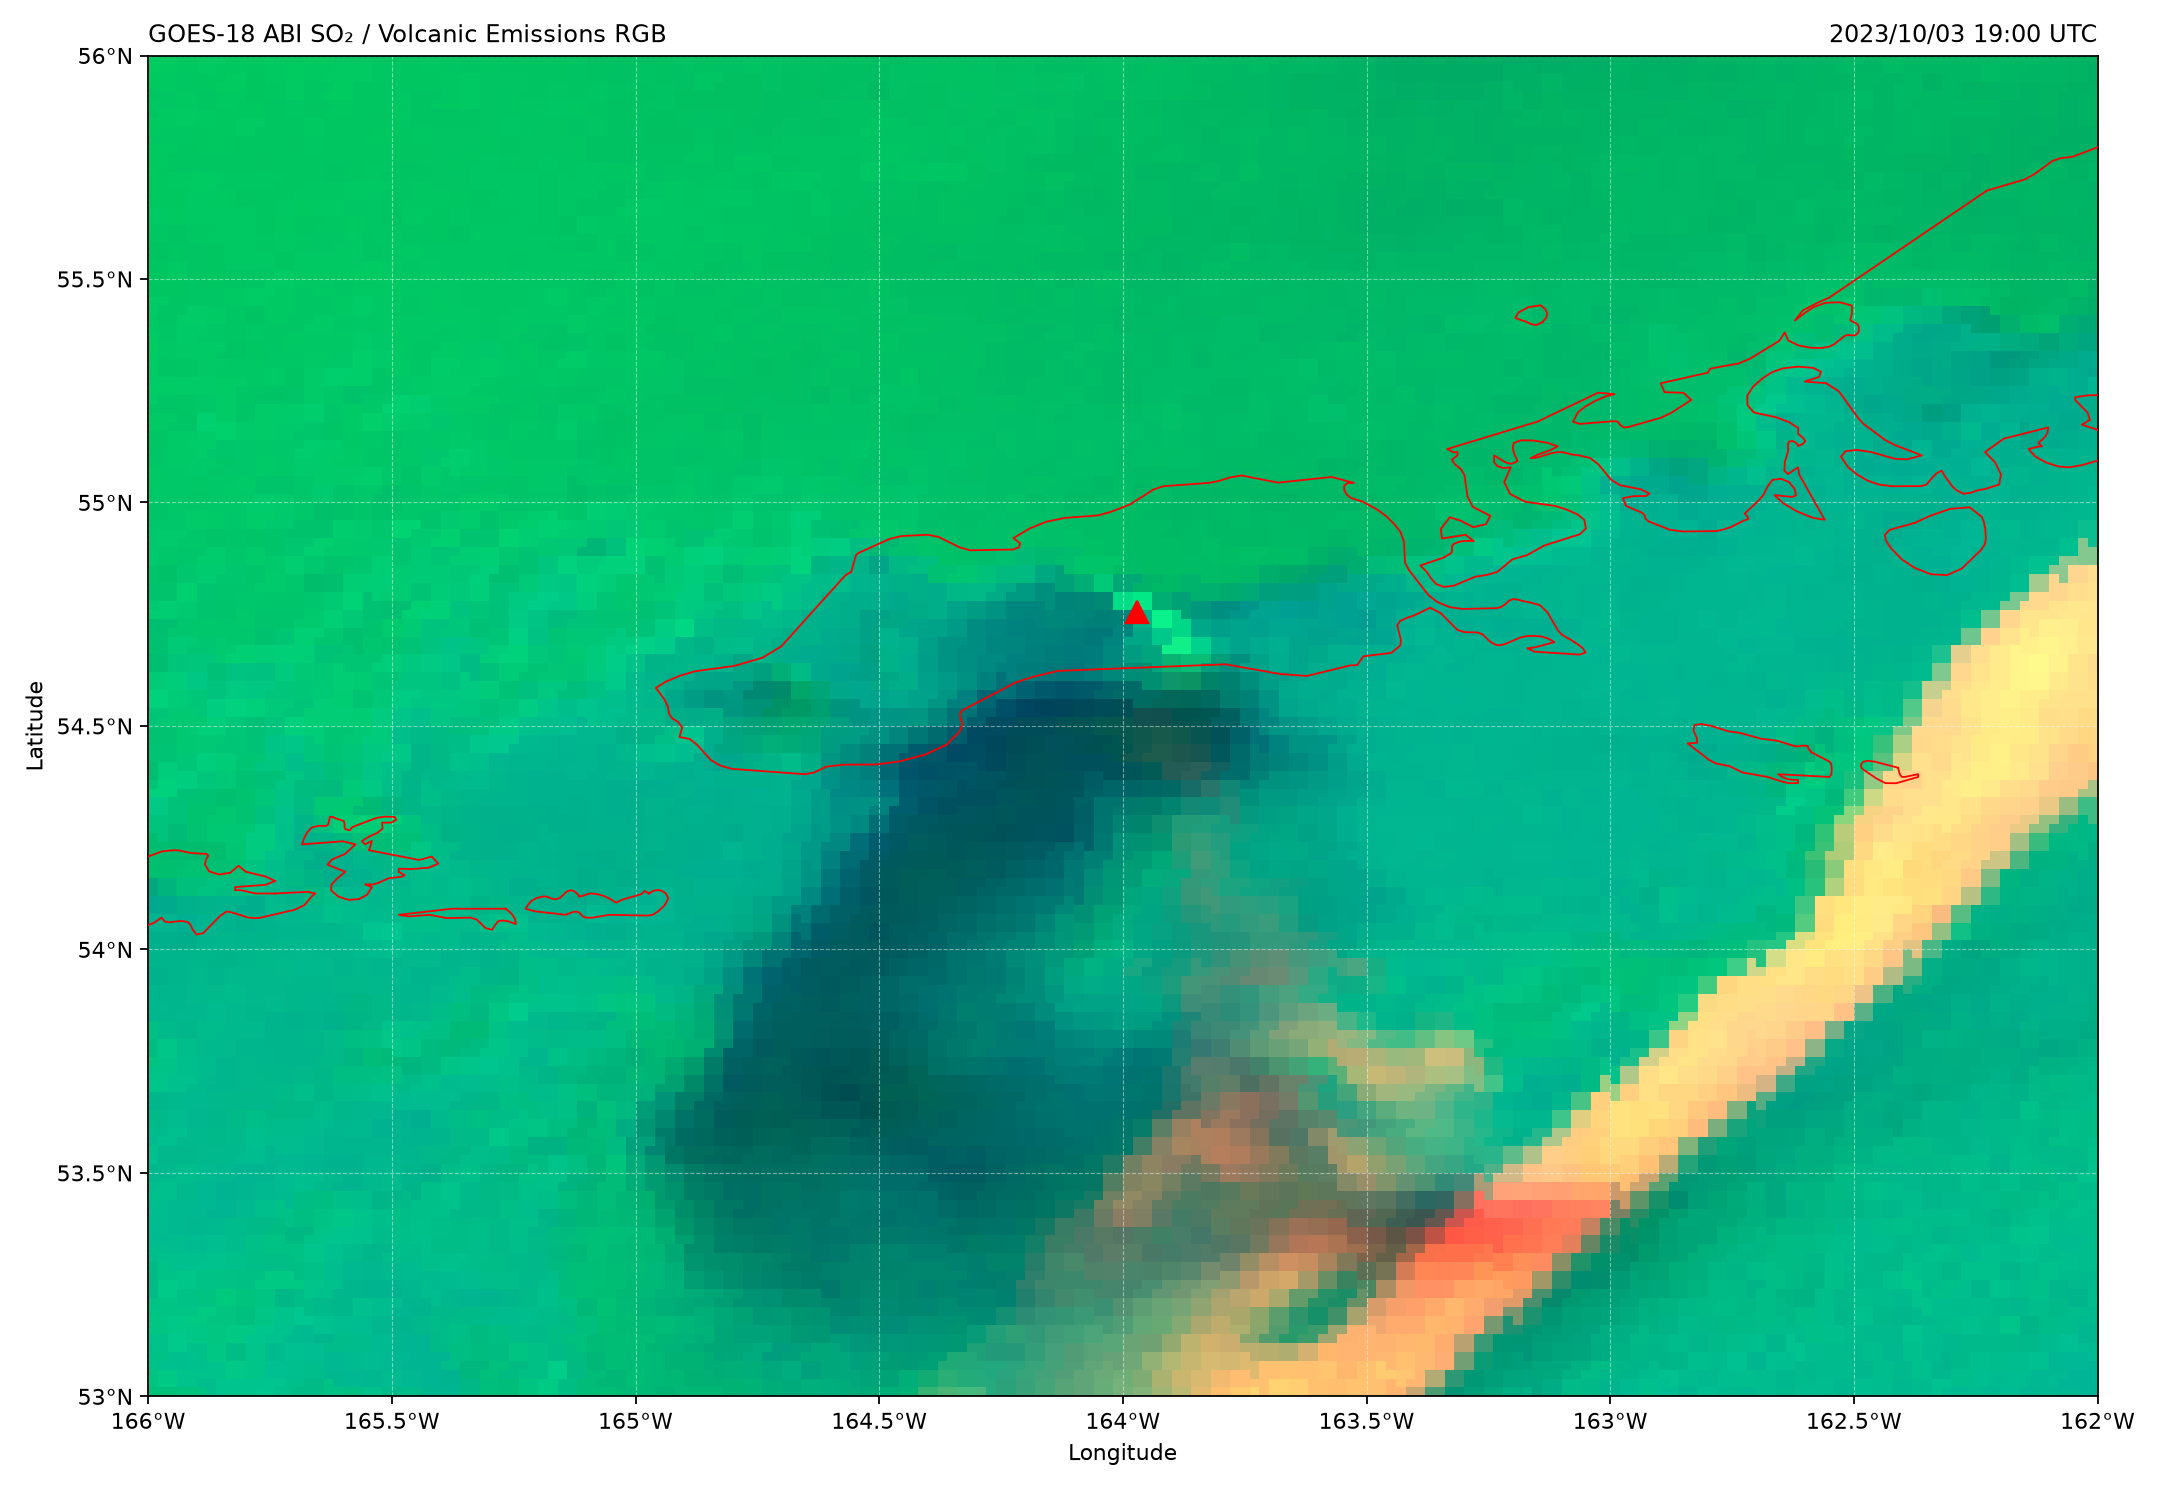

In [3]:
files = download_coverage(DATA_DIR, "full_disk", CHANNELS)
scene = Scene(reader="abi_l1b", filenames=files)
scene.load([COMPOSITE], generate=True)

# Read from the ABI projection, then put the crop on a regular lon/lat grid
# (EPSG:4326 is plain rectangular over this small domain).
cropped = crop_and_resample_scene(scene, domain=DOMAIN, resolution=DOMAIN_RESOLUTION)
try:
    cropped[COMPOSITE]
except KeyError:
    cropped.load([COMPOSITE], generate=True)

save_map(
    cropped,
    COMPOSITE,
    OUTPUT,
    title=f"GOES-18 ABI {PRODUCT_LABEL}",
)
display(Image(filename=str(OUTPUT)))


## Notes

* Thick upper-level clouds can mask a gas signal, and low clouds can
  resemble low-level SO₂.
* Command line: `python examples/render_satellite.py --sensor goes --files "data/goes/*.nc" --composite volcanic_emissions --domain shishaldin`.